# 🏠 House Price Prediction Project

## 1. Import Libraries

In [81]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline


pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## 2. Load Dataset

In [82]:
#تحميل البيانات

df = pd.read_csv("data/house_prices.csv")

In [83]:
#عرض  اول 5 صفوف

df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [84]:
#عرض اخر 5 صفوف

df.tail()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
187526,187526,3 BHK Ready to Occupy Flat for sale in Bollywo...,This magnificent 3 BHK Flat is available for s...,63 Lac,3225.0,zirakpur,NaN,Ready to Move,2 out of 4,New Property,Semi-Furnished,East,Garden/Park,Bollywood Esencia,3,3,1 Covered,Freehold,1953 sqft,NaN,NaN
187527,187527,3 BHK Ready to Occupy Flat for sale in Sushma ...,Have a look at this immaculate 3 BHK flat for ...,55 Lac,3274.0,zirakpur,NaN,Ready to Move,4 out of 6,Resale,Unfurnished,North - East,"Garden/Park, Main Road",Sushma Urban Views,3,NaN,1 Covered,NaN,1680 sqft,NaN,NaN
187528,187528,3 BHK Ready to Occupy Flat for sale in Bollywo...,"Gazipur, Zirakpur has an appealing 3 BHK flat ...",76 Lac,4343.0,zirakpur,1250 sqft,Ready to Move,1 out of 3,Resale,Furnished,East,"Garden/Park, Main Road",Bollywood Esencia,3,2,"1 Covered,",Freehold,NaN,NaN,NaN
187529,187529,2 BHK Ready to Occupy Flat for sale in Friends...,Up for immediate sale is a 2 BHK apartment in ...,30 Lac,4231.0,zirakpur,NaN,Ready to Move,2 out of 2,Resale,Semi-Furnished,NaN,Main Road,Friends Enclave,2,NaN,NaN,NaN,709 sqft,NaN,NaN
187530,187530,3 BHK Ready to Occupy Flat for sale in Affinit...,This exquisite 3 BHK Flat is offered for sale ...,1.18 Cr,6162.0,zirakpur,NaN,Ready to Move,5 out of 13,Resale,Semi-Furnished,North - East,"Garden/Park, Pool",Affinity Greens,4,4,1 Covered,Freehold,1915 sqft,NaN,NaN


## 3. Data Understanding

In [85]:
#عدد الصفوف والاعمده

print("Dataset Shape :", df.shape)

Dataset Shape : (187531, 21)


In [86]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [87]:
#الاحصائيات

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,187531.0,NaN,NaN,NaN,93765.0,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,184508,65634,Multistorey apartment is available for sale. I...,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),187531,1561,Call for Price,9684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),169866.0,NaN,NaN,NaN,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
location,187531,81,new-delhi,27599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,106858,2758,1000 sqft,5285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,186916,1,Ready to Move,186916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,180454,947,2 out of 4,12433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,187448,4,Resale,144172,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [88]:
#فحص القيم الفارغه
print("\nMissing Values:")
df.isnull().sum()


Missing Values:


Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [89]:
#فحص الصفوف المكرره

df.duplicated().sum()

np.int64(0)

In [90]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
187526    False
187527    False
187528    False
187529    False
187530    False
Length: 187531, dtype: bool

In [91]:
df.columns

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area'],
      dtype='str')

In [92]:
df.dtypes

Index                  int64
Title                    str
Description              str
Amount(in rupees)        str
Price (in rupees)    float64
location                 str
Carpet Area              str
Status                   str
Floor                    str
Transaction              str
Furnishing               str
facing                   str
overlooking              str
Society                  str
Bathroom                 str
Balcony                  str
Car Parking              str
Ownership                str
Super Area               str
Dimensions           float64
Plot Area            float64
dtype: object

# 4.Data Cleaning

In [93]:
print(df.shape)

(187531, 21)


In [ ]:
#نسبه ال missing values لكل عمود 

missing = (
    df.isnull()
      .mean()
      .sort_values(ascending=False)
      * 100
)

missing[missing > 0]

Plot Area            100.000000
Dimensions           100.000000
Society               58.485264
Super Area            57.422506
Car Parking           55.114621
overlooking           43.425354
Carpet Area           43.018488
facing                37.451408
Ownership             34.936624
Balcony               26.094352
Price (in rupees)      9.419776
Floor                  3.773776
Description            1.612000
Furnishing             1.544811
Bathroom               0.441527
Status                 0.327946
Transaction            0.044259
dtype: float64

In [ ]:
# تنظيف عمود السعر


def parse_price(x):

    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower().replace(",", "")

    if "call for price" in x:
        return np.nan

    try:

        if "lac" in x:
            return float(x.replace("lac","").strip()) * 100000

        elif "cr" in x:
            return float(x.replace("cr","").strip()) * 10000000

        else:
            return float(x)

    except:
        return np.nan

In [96]:
df["price_clean"] = df["Amount(in rupees)"].apply(parse_price)

df = df.dropna(subset=["price_clean"])

df[["Amount(in rupees)", "price_clean"]].head()

,Amount(in rupees),price_clean
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0


In [ ]:
# تنظيف لب carpet area


def extract_area(area):

    if pd.isna(area):
        return np.nan

    area = str(area).lower()

    num = re.findall(r'[\d.]+', area)

    if len(num)==0:
        return np.nan

    value = float(num[0])

    if "sqm" in area:
        value *= 10.764

    return value

In [98]:
df["carpet_area_sqft"] = df["Carpet Area"].apply(extract_area)

df[["Carpet Area","carpet_area_sqft"]].head()

,Carpet Area,carpet_area_sqft
0,500 sqft,500.0
1,473 sqft,473.0
2,779 sqft,779.0
3,530 sqft,530.0
4,635 sqft,635.0


In [ ]:
#تنظيف ال floor


def extract_floor(x):

    if pd.isna(x):
        return np.nan

    x = str(x).lower()

    if "ground" in x:
        return 0

    num = re.findall(r'\d+', x)

    if len(num)==0:
        return np.nan

    return int(num[0])

In [100]:
df["floor_num"] = df["Floor"].apply(extract_floor)

df[["Floor","floor_num"]].head()

,Floor,floor_num
0,10 out of 11,10.0
1,3 out of 22,3.0
2,10 out of 29,10.0
3,1 out of 3,1.0
4,20 out of 42,20.0


In [ ]:
#تنظيف ال bathroom


df["Bathroom"] = (
    pd.to_numeric(df["Bathroom"], errors="coerce")
)

In [ ]:
#تنظيف Balcony

df["Balcony"] = (
    pd.to_numeric(df["Balcony"], errors="coerce")
)

In [ ]:
#تنظيف Car Parking

df["Car Parking"] = (
    pd.to_numeric(df["Car Parking"], errors="coerce")
)

In [ ]:
#ملء الـ Missing Values

numeric_cols = [
    "Bathroom",
    "Balcony",
    "Car Parking",
    "floor_num",
    "carpet_area_sqft"
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
#تجميع الـ Locations

top_locations = (
    df["location"]
    .value_counts()
    .head(50)
    .index
)

In [106]:
df["location_grouped"] = df["location"].apply(
    lambda x: x if x in top_locations else "Other"
)

In [ ]:
#حذف الأعمدة غير المهمة


drop_columns = [
    "Title",
    "Description",
    "Amount(in rupees)",
    "Price (in rupees)",
    "Index"
]

drop_columns = [c for c in drop_columns if c in df.columns]

df.drop(columns=drop_columns, inplace=True)

In [ ]:
#ازاله الصفوف المكرره

print("Before:", df.shape)

df.drop_duplicates(inplace=True)

print("After:", df.shape)

Before: (177847, 20)
After: (63950, 20)


In [ ]:
#حذف الأعمدة اللي نسبة الـ Missing فيها كبيرة جدًا (لو موجودة)

missing_percent = df.isnull().mean() * 100

missing_percent[missing_percent > 40]

Carpet Area     43.734167
overlooking     42.602033
Society         56.648944
Car Parking    100.000000
Super Area      56.403440
Dimensions     100.000000
Plot Area      100.000000
dtype: float64

In [ ]:
#تنظيف الـ Location


df["location"] = df["location"].str.strip()

In [ ]:
#إزالة الـ Outliers

df = df[df["carpet_area_sqft"] > 200]

df = df[df["carpet_area_sqft"] < 10000]

In [ ]:
#إزالة الـ Outliers بالنسبه للسعر


Q1 = df["price_clean"].quantile(0.25)
Q3 = df["price_clean"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["price_clean"] >= lower) &
        (df["price_clean"] <= upper)]

In [116]:
df.dtypes

location                str
Carpet Area             str
Status                  str
Floor                   str
Transaction             str
Furnishing              str
facing                  str
overlooking             str
Society                 str
Bathroom            float64
Balcony             float64
Car Parking         float64
Ownership               str
Super Area              str
Dimensions          float64
Plot Area           float64
price_clean         float64
carpet_area_sqft    float64
floor_num           float64
location_grouped        str
dtype: object

In [117]:
df.head()

,location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area,price_clean,carpet_area_sqft,floor_num,location_grouped
0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1.0,2.0,NaN,NaN,NaN,NaN,NaN,4200000.0,500.0,10.0,thane
1,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2.0,2.0,NaN,Freehold,NaN,NaN,NaN,9800000.0,473.0,3.0,thane
2,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2.0,2.0,NaN,Freehold,NaN,NaN,NaN,14000000.0,779.0,10.0,thane
3,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,2500000.0,530.0,1.0,thane
4,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2.0,2.0,NaN,Co-operative Society,NaN,NaN,NaN,16000000.0,635.0,20.0,thane


In [118]:
print(df.shape)

(57223, 20)


# 5. EDA

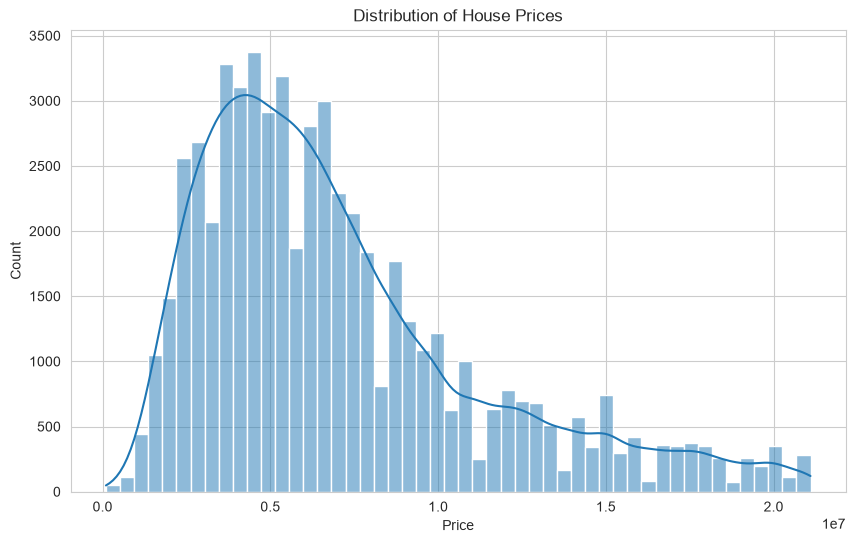


نلاحظ أن أغلب أسعار المنازل تقع في الفئات السعرية المنخفضة والمتوسطة،
بينما عدد المنازل ذات الأسعار المرتفعة قليل، لذلك توزيع الأسعار ليس متساويًا.



In [ ]:
#Distribution of Price

plt.figure(figsize=(10,6))

sns.histplot(df["price_clean"], bins=50, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()


print("""
نلاحظ أن أغلب أسعار المنازل تقع في الفئات السعرية المنخفضة والمتوسطة،
بينما عدد المنازل ذات الأسعار المرتفعة قليل، لذلك توزيع الأسعار ليس متساويًا.
""")

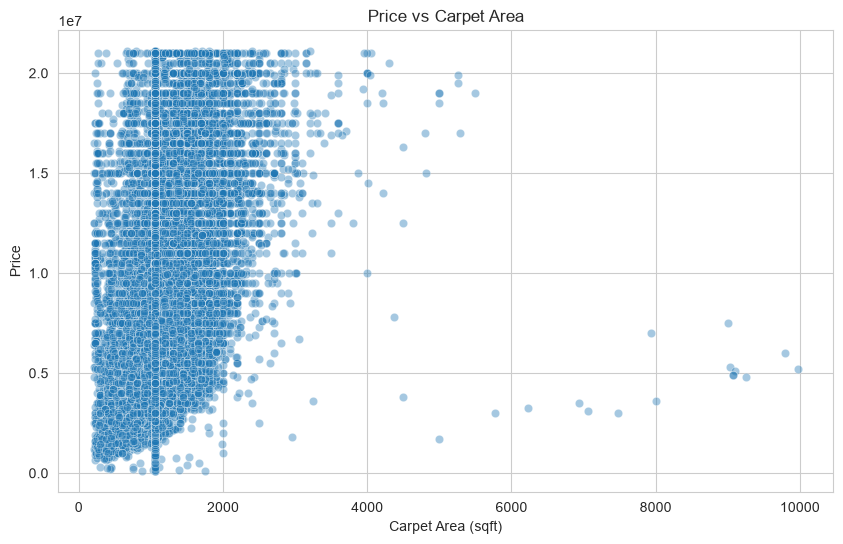


يوجد علاقة طردية بين مساحة المنزل وسعره،
فكلما زادت المساحة زاد السعر في أغلب الحالات.



In [ ]:
#Price vs Carpet Area

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["carpet_area_sqft"],
    y=df["price_clean"],
    alpha=0.4
)

plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price")
plt.title("Price vs Carpet Area")

plt.show()

print("""
يوجد علاقة طردية بين مساحة المنزل وسعره،
فكلما زادت المساحة زاد السعر في أغلب الحالات.
""")

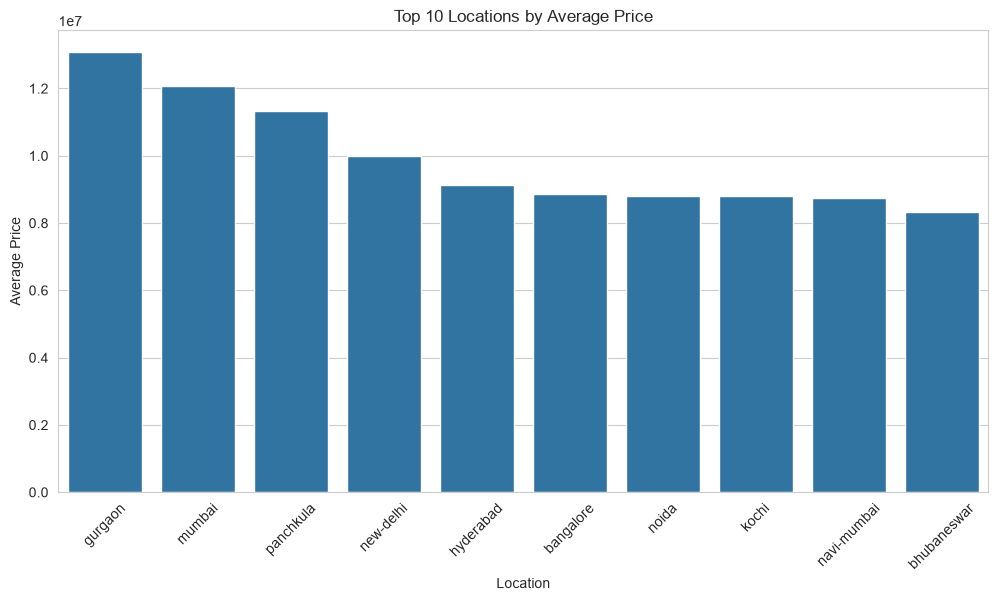


متوسط أسعار المنازل يختلف من منطقة لأخرى،
مما يدل على أن الموقع يعتبر من أهم العوامل المؤثرة في سعر المنزل.



In [ ]:
#Average Price by Location

top10_locations = (
    df.groupby("location_grouped")["price_clean"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10_locations.index,
    y=top10_locations.values
)

plt.xticks(rotation=45)

plt.xlabel("Location")
plt.ylabel("Average Price")

plt.title("Top 10 Locations by Average Price")

plt.show()

print("""
متوسط أسعار المنازل يختلف من منطقة لأخرى،
مما يدل على أن الموقع يعتبر من أهم العوامل المؤثرة في سعر المنزل.
""")

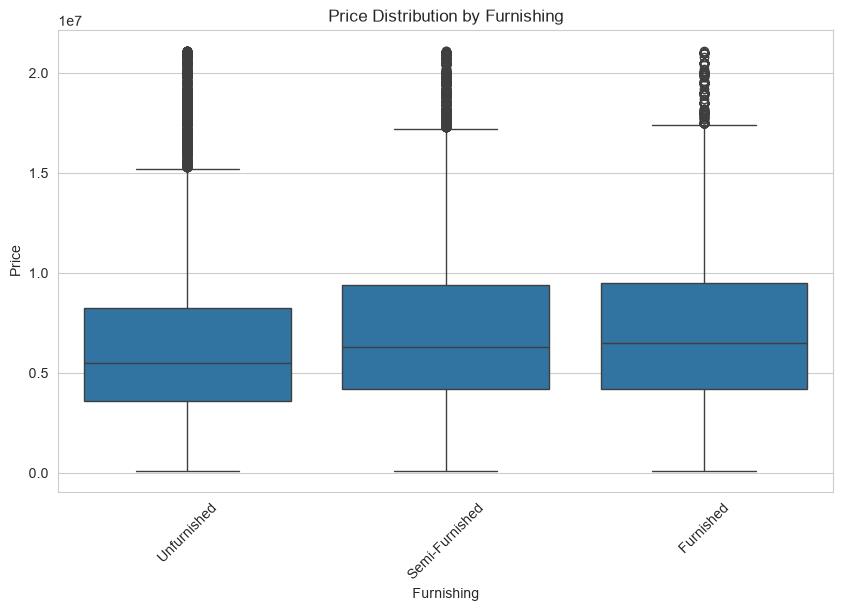


حالة التشطيب تؤثر على سعر المنزل،
حيث تميل المنازل كاملة التشطيب إلى أن تكون أسعارها أعلى من غيرها.



In [ ]:
#Price vs Furnishing

plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["Furnishing"],
    y=df["price_clean"]
)

plt.xticks(rotation=45)

plt.xlabel("Furnishing")
plt.ylabel("Price")

plt.title("Price Distribution by Furnishing")

plt.show()

print("""
حالة التشطيب تؤثر على سعر المنزل،
حيث تميل المنازل كاملة التشطيب إلى أن تكون أسعارها أعلى من غيرها.
""")

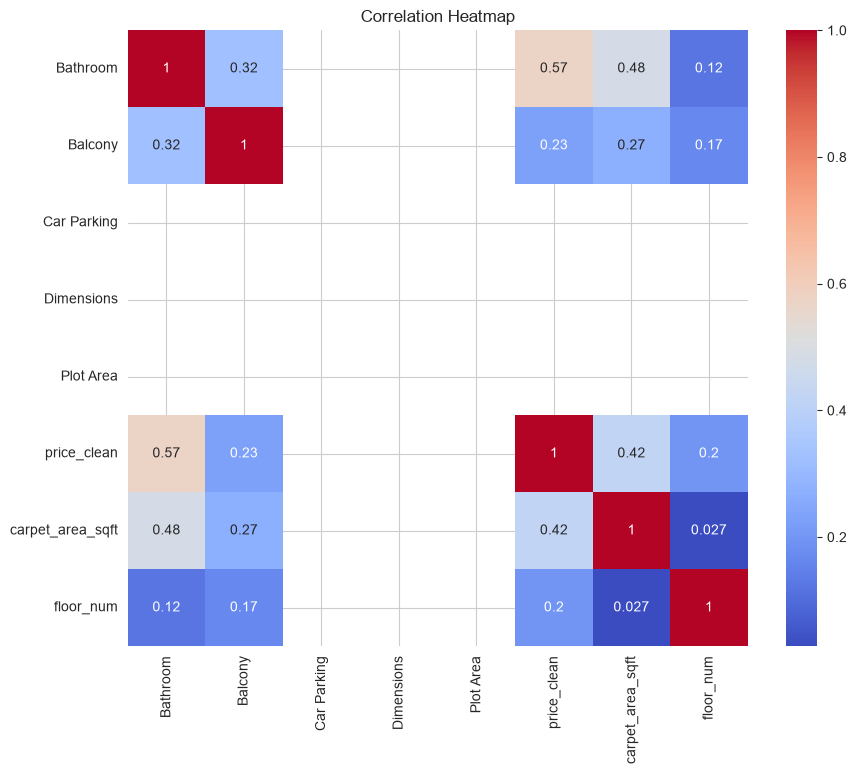


يوضح هذا الرسم قوة العلاقة بين المتغيرات الرقمية،
ويساعد في معرفة أكثر الخصائص تأثيرًا على سعر المنزل.



In [ ]:
#Correlation Heatmap

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

print("""
يوضح هذا الرسم قوة العلاقة بين المتغيرات الرقمية،
ويساعد في معرفة أكثر الخصائص تأثيرًا على سعر المنزل.
""")

In [128]:
print(df.shape)

df.head()

(57223, 20)


,location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area,price_clean,carpet_area_sqft,floor_num,location_grouped
0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1.0,2.0,NaN,NaN,NaN,NaN,NaN,4200000.0,500.0,10.0,thane
1,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2.0,2.0,NaN,Freehold,NaN,NaN,NaN,9800000.0,473.0,3.0,thane
2,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2.0,2.0,NaN,Freehold,NaN,NaN,NaN,14000000.0,779.0,10.0,thane
3,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,2500000.0,530.0,1.0,thane
4,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2.0,2.0,NaN,Co-operative Society,NaN,NaN,NaN,16000000.0,635.0,20.0,thane


# 6.Feature Engineering.


In [190]:
df["price_per_sqft"] = (
    df["price_clean"] / df["carpet_area_sqft"]
)

df[["price_clean","carpet_area_sqft","price_per_sqft"]].head()

,price_clean,carpet_area_sqft,price_per_sqft
0,4200000.0,500.0,8400.000000
1,9800000.0,473.0,20718.816068
2,14000000.0,779.0,17971.758665
3,2500000.0,530.0,4716.981132
4,16000000.0,635.0,25196.850394


In [191]:
df = df[df["price_per_sqft"] > 100]

df = df[df["price_per_sqft"] < 50000]

df.shape

(57156, 25)

In [192]:
df["has_balcony"] = np.where(df["Balcony"] > 0, 1, 0)

df[["Balcony","has_balcony"]].head()

,Balcony,has_balcony
0,2.0,1
1,2.0,1
2,2.0,1
3,1.0,1
4,2.0,1


In [193]:
df["has_parking"] = np.where(df["Car Parking"] > 0, 1, 0)

df[["Car Parking","has_parking"]].head()

,Car Parking,has_parking
0,NaN,0
1,NaN,0
2,NaN,0
3,NaN,0
4,NaN,0


In [194]:
features = [

    "location_grouped",

    "carpet_area_sqft",

    "super_area_sqft",

    "plot_area_sqft",

    "Bathroom",

    "Balcony",

    "Car Parking",

    "floor_num",

    "Furnishing",

    "Transaction",

    "Ownership",

    "Status",

    "facing",

    "overlooking",

    "has_balcony",

    "has_parking"

]

target = "price_clean"

In [195]:
def extract_super_area(area):

    if pd.isna(area):
        return np.nan

    area = str(area).lower()

    num = re.findall(r'[\d.]+', area)

    if len(num) == 0:
        return np.nan

    value = float(num[0])

    if "sqm" in area:
        value *= 10.764

    return value

In [196]:
df["super_area_sqft"] = df["Super Area"].apply(extract_super_area)

df[["Super Area", "super_area_sqft"]].head()

,Super Area,super_area_sqft
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


In [197]:
def extract_plot_area(area):

    if pd.isna(area):
        return np.nan

    area = str(area).lower()

    num = re.findall(r'[\d.]+', area)

    if len(num) == 0:
        return np.nan

    value = float(num[0])

    if "sqm" in area:
        value *= 10.764

    return value

In [198]:
df["plot_area_sqft"] = df["Plot Area"].apply(extract_plot_area)

df[["Plot Area", "plot_area_sqft"]].head()

,Plot Area,plot_area_sqft
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


In [199]:
df["super_area_sqft"] = df["super_area_sqft"].fillna(
    df["super_area_sqft"].median()
)

df["plot_area_sqft"] = df["plot_area_sqft"].fillna(
    df["plot_area_sqft"].median()
)

In [200]:
X = df[features]

y = df[target]

print(X.shape)

print(y.shape)

(57156, 16)
(57156,)


In [201]:
X.head()

,location_grouped,carpet_area_sqft,super_area_sqft,plot_area_sqft,Bathroom,Balcony,Car Parking,floor_num,Furnishing,Transaction,Ownership,Status,facing,overlooking,has_balcony,has_parking
0,thane,500.0,1175.0,NaN,1.0,2.0,NaN,10.0,Unfurnished,Resale,NaN,Ready to Move,NaN,NaN,1,0
1,thane,473.0,1175.0,NaN,2.0,2.0,NaN,3.0,Semi-Furnished,Resale,Freehold,Ready to Move,East,Garden/Park,1,0
2,thane,779.0,1175.0,NaN,2.0,2.0,NaN,10.0,Unfurnished,Resale,Freehold,Ready to Move,East,Garden/Park,1,0
3,thane,530.0,1175.0,NaN,1.0,1.0,NaN,1.0,Unfurnished,Resale,NaN,Ready to Move,NaN,NaN,1,0
4,thane,635.0,1175.0,NaN,2.0,2.0,NaN,20.0,Unfurnished,Resale,Co-operative Society,Ready to Move,West,"Garden/Park, Main Road",1,0


In [202]:
y.head()

0     4200000.0
1     9800000.0
2    14000000.0
3     2500000.0
4    16000000.0
Name: price_clean, dtype: float64

In [203]:
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.ensemble import GradientBoostingRegressor

In [204]:
categorical_features = [

    "location_grouped",

    "Furnishing",

    "Transaction",

    "Ownership",

    "Status",

    "facing",

    "overlooking"

]

numeric_features = [

    "carpet_area_sqft",

    "super_area_sqft",

    "plot_area_sqft",

    "Bathroom",

    "Balcony",

    "Car Parking",

    "floor_num",

    "has_balcony",

    "has_parking"

]

In [205]:
print("Categorical Features")

print(categorical_features)

print()

print("Numeric Features")

print(numeric_features)

Categorical Features
['location_grouped', 'Furnishing', 'Transaction', 'Ownership', 'Status', 'facing', 'overlooking']

Numeric Features
['carpet_area_sqft', 'super_area_sqft', 'plot_area_sqft', 'Bathroom', 'Balcony', 'Car Parking', 'floor_num', 'has_balcony', 'has_parking']


In [206]:
preprocessor = ColumnTransformer(

    transformers=[

        (

            "num",

            Pipeline([

                ("imputer", SimpleImputer(strategy="median"))

            ]),

            numeric_features

        ),

        (

            "cat",

            Pipeline([

                ("imputer", SimpleImputer(strategy="most_frequent")),

                ("encoder", OneHotEncoder(handle_unknown="ignore"))

            ]),

            categorical_features

        )

    ]

)

In [207]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (45724, 16)
Testing Shape : (11432, 16)


In [208]:
X_train.head()

,location_grouped,carpet_area_sqft,super_area_sqft,plot_area_sqft,Bathroom,Balcony,Car Parking,floor_num,Furnishing,Transaction,Ownership,Status,facing,overlooking,has_balcony,has_parking
173266,palghar,1050.0,520.0,NaN,1.0,2.0,NaN,0.0,Furnished,Resale,NaN,Ready to Move,NaN,NaN,1,0
149792,bhiwadi,1050.0,950.0,NaN,2.0,2.0,NaN,5.0,Unfurnished,Resale,NaN,Ready to Move,South -West,NaN,1,0
166821,jamshedpur,1050.0,886.0,NaN,2.0,2.0,NaN,4.0,Unfurnished,Resale,NaN,Ready to Move,NaN,NaN,1,0
117689,new-delhi,1100.0,1175.0,NaN,2.0,1.0,NaN,1.0,Semi-Furnished,Resale,Freehold,Ready to Move,North - East,"Garden/Park, Main Road",1,0
165768,guwahati,970.0,1175.0,NaN,2.0,2.0,NaN,5.0,Semi-Furnished,Resale,Freehold,Ready to Move,East,Main Road,1,0


In [209]:
linear_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", LinearRegression())

    ]

)

In [210]:
linear_pipeline.fit(

    X_train,

    y_train

)

c:\Users\msi\OneDrive\Desktop\HousePricePrediction\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['plot_area_sqft' 'Car Parking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['location_grouped','carpet_area_sqft','super_area_sqft',...,'overlooking', 'has_balcony','has_parking']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passe

In [211]:
linear_predictions = linear_pipeline.predict(

    X_test

)

c:\Users\msi\OneDrive\Desktop\HousePricePrediction\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['plot_area_sqft' 'Car Parking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [212]:
linear_mae = mean_absolute_error(

    y_test,

    linear_predictions

)

linear_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        linear_predictions

    )

)

linear_r2 = r2_score(

    y_test,

    linear_predictions

)

print("Linear Regression Results")

print("-" * 35)

print(f"MAE  : {linear_mae:,.2f}")

print(f"RMSE : {linear_rmse:,.2f}")

print(f"R²   : {linear_r2:.4f}")

Linear Regression Results
-----------------------------------
MAE  : 1,911,516.37
RMSE : 2,621,847.83
R²   : 0.6210


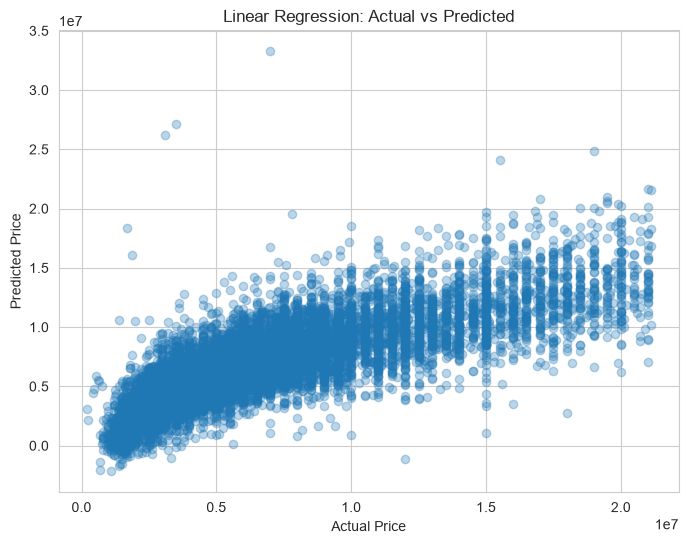

In [213]:
plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    linear_predictions,

    alpha=0.3

)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [214]:
random_forest_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", RandomForestRegressor(

            n_estimators=300,
            max_depth=25,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt",
            bootstrap=True,
            random_state=42,
            n_jobs=-1

        ))

    ]

)

In [215]:
random_forest_pipeline.fit(

    X_train,

    y_train

)

c:\Users\msi\OneDrive\Desktop\HousePricePrediction\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['plot_area_sqft' 'Car Parking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['location_grouped','carpet_area_sqft','super_area_sqft',...,'overlooking', 'has_balcony','has_parking']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passe

In [216]:
rf_predictions = random_forest_pipeline.predict(

    X_test

)

c:\Users\msi\OneDrive\Desktop\HousePricePrediction\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['plot_area_sqft' 'Car Parking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [217]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("-"*40)
print(f"MAE  : {rf_mae:,.2f}")
print(f"RMSE : {rf_rmse:,.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Results
----------------------------------------
MAE  : 1,756,171.50
RMSE : 2,403,121.82
R²   : 0.6816


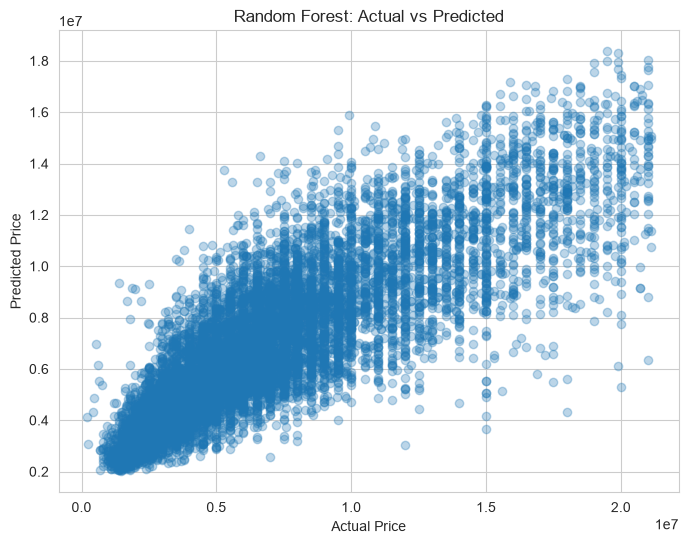

In [218]:
plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    rf_predictions,

    alpha=0.3

)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Random Forest: Actual vs Predicted")

plt.show()

In [219]:
gradient_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", GradientBoostingRegressor(

            n_estimators=100,

            learning_rate=0.1,

            max_depth=3,

            random_state=42

        ))

    ]

)

In [220]:
gradient_pipeline.fit(

    X_train,

    y_train

)

c:\Users\msi\OneDrive\Desktop\HousePricePrediction\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['plot_area_sqft' 'Car Parking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['location_grouped','carpet_area_sqft','super_area_sqft',...,'overlooking', 'has_balcony','has_parking']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passe

In [221]:
gb_predictions = gradient_pipeline.predict(

    X_test

)

c:\Users\msi\OneDrive\Desktop\HousePricePrediction\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['plot_area_sqft' 'Car Parking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [222]:
gb_mae = mean_absolute_error(

    y_test,

    gb_predictions

)

gb_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        gb_predictions

    )

)

gb_r2 = r2_score(

    y_test,

    gb_predictions

)

print("Gradient Boosting Results")

print("-" * 35)

print(f"MAE  : {gb_mae:,.2f}")

print(f"RMSE : {gb_rmse:,.2f}")

print(f"R²   : {gb_r2:.4f}")

Gradient Boosting Results
-----------------------------------
MAE  : 1,856,961.23
RMSE : 2,523,863.36
R²   : 0.6488


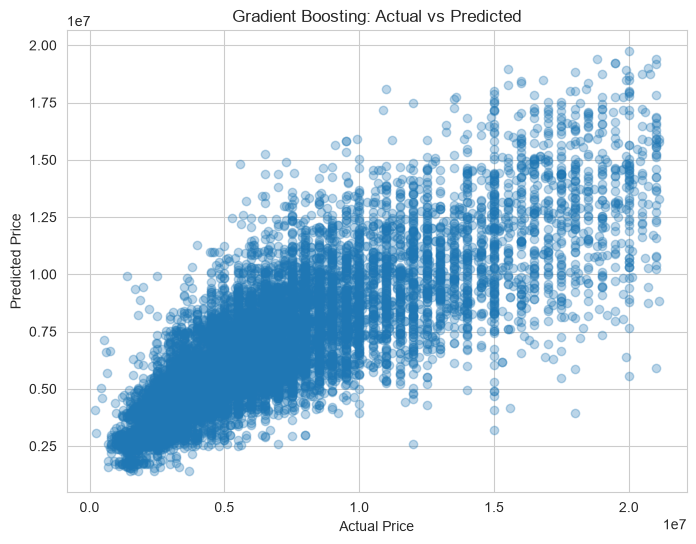

In [223]:
plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    gb_predictions,

    alpha=0.3

)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Gradient Boosting: Actual vs Predicted")

plt.show()

In [224]:
results = pd.DataFrame({

    "Model": [

        "Linear Regression",

        "Random Forest",

        "Gradient Boosting"

    ],

    "MAE": [

        linear_mae,

        rf_mae,

        gb_mae

    ],

    "RMSE": [

        linear_rmse,

        rf_rmse,

        gb_rmse

    ],

    "R²": [

        linear_r2,

        rf_r2,

        gb_r2

    ]

})

results

,Model,MAE,RMSE,R²
0,Linear Regression,1.911516e+06,2.621848e+06,0.620973
1,Random Forest,1.756171e+06,2.403122e+06,0.681575
2,Gradient Boosting,1.856961e+06,2.523863e+06,0.648774


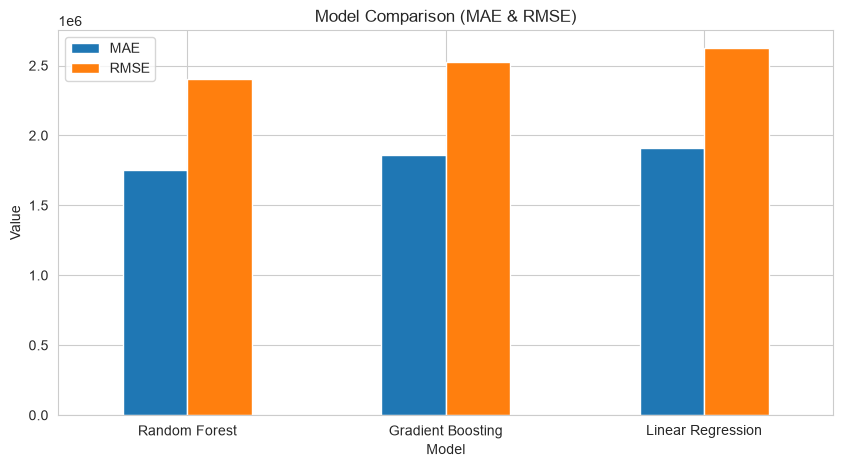

In [233]:
comparison = results.set_index("Model")

comparison[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Comparison (MAE & RMSE)")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.show()

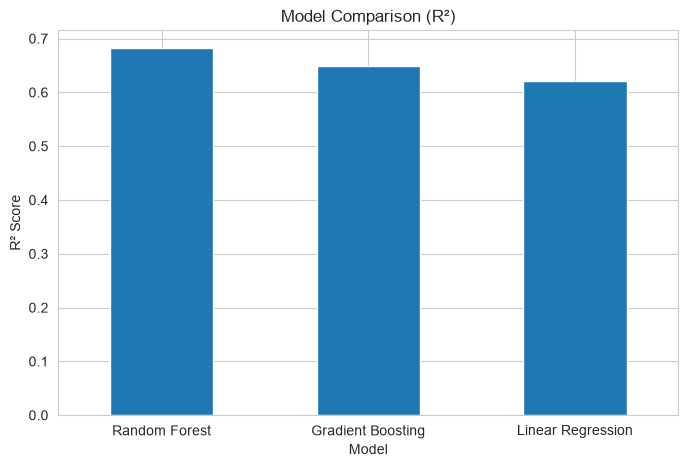

In [234]:
comparison["R²"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Comparison (R²)")
plt.ylabel("R² Score")
plt.xticks(rotation=0)
plt.show()

# *حفظ افضل مودل*

In [235]:
import joblib

In [238]:
joblib.dump(
    random_forest_pipeline,
    "house_price_model.pkl"
)

print('Model Saved Successfully')

Model Saved Successfully


In [239]:
import json

locations = sorted(df["location_grouped"].unique())

with open("locations.json", "w") as f:
    json.dump(locations, f)

print("locations.json saved successfully")

locations.json saved successfully


In [ ]:
#model testing

sample = X.iloc[[0]]

sample

,location_grouped,carpet_area_sqft,super_area_sqft,plot_area_sqft,Bathroom,Balcony,Car Parking,floor_num,Furnishing,Transaction,Ownership,Status,facing,overlooking,has_balcony,has_parking
0,thane,500.0,1175.0,NaN,1.0,2.0,NaN,10.0,Unfurnished,Resale,NaN,Ready to Move,NaN,NaN,1,0


In [242]:
prediction = random_forest_pipeline.predict(sample)

print("Expected price is:")

print(prediction[0])

Expected price is:
5167876.216417172


c:\Users\msi\OneDrive\Desktop\HousePricePrediction\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['plot_area_sqft' 'Car Parking']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [243]:
print("""

تم حفظ أفضل نموذج بعد الانتهاء من المقارنة بين جميع النماذج.

كما تم حفظ قائمة المناطق لاستخدامها داخل واجهة المستخدم
أثناء عملية التنبؤ بأسعار المنازل.

""")



تم حفظ أفضل نموذج بعد الانتهاء من المقارنة بين جميع النماذج.

كما تم حفظ قائمة المناطق لاستخدامها داخل واجهة المستخدم
أثناء عملية التنبؤ بأسعار المنازل.


